# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap
import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)
gapminder = px.data.gapminder()

try:
    centroids = pd.read_csv("country_centroids_computed.csv")
except:
    centroids = gapminder[['iso_alpha']].drop_duplicates()
    centroids['longitude'] = 0.0
    centroids['latitude'] = 0.0

gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)
print(f"Loaded {gapminder.country.nunique()} countries.")

Loaded 142 countries.


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [10]:
import plotly.express as px
# Task 1: Choropleth comparison
fig1 = px.choropleth(gap_latest, locations="iso_alpha", color="total_gdp", title="Total GDP (Count)")
fig1.show()
fig2 = px.choropleth(gap_latest, locations="iso_alpha", color="gdpPercap", title="GDP per Capita (Rate)")
fig2.show()
print("Top 5 Total GDP:\n", gap_latest.nlargest(5, 'total_gdp')[['country', 'total_gdp']])
print("\nTop 5 GDP per Cap:\n", gap_latest.nlargest(5, 'gdpPercap')[['country', 'gdpPercap']])

Top 5 Total GDP:
            country     total_gdp
134  United States  1.293446e+13
24           China  6.539501e+12
66           Japan  4.035135e+12
58           India  2.722925e+12
47         Germany  2.650871e+12

Top 5 GDP per Cap:
            country    gdpPercap
95          Norway  49357.19017
71          Kuwait  47306.98978
113      Singapore  47143.17964
134  United States  42951.65309
62         Ireland  40675.99635


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

_Your answer:_

## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

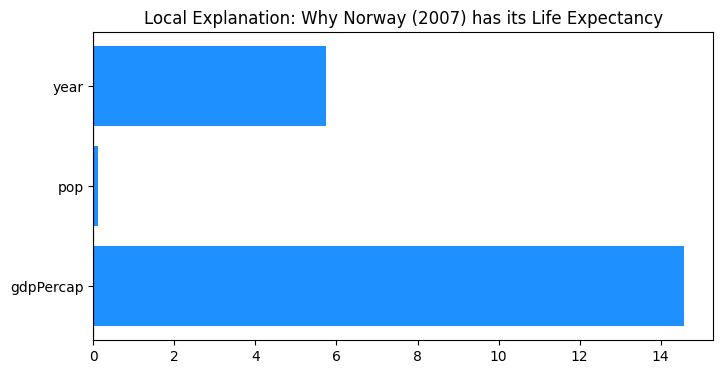

In [11]:
X = gapminder[["gdpPercap", "pop", "year"]].values
y = gapminder["lifeExp"].values
# Task 2: SHAP Local Explanation
rf = RandomForestRegressor(n_estimators=100, random_state=0).fit(X, y)
explainer = shap.TreeExplainer(rf)
shap_v = explainer.shap_values(X)
row = gapminder.index[(gapminder.country == "Norway") & (gapminder.year == 2007)][0]
plt.figure(figsize=(8, 4))
plt.barh(["gdpPercap", "pop", "year"], shap_v[row], color=['dodgerblue' if v > 0 else 'crimson' for v in shap_v[row]])
plt.axvline(0, color='black', lw=0.8)
plt.title("Local Explanation: Why Norway (2007) has its Life Expectancy")
plt.show()

**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

_Your answer:_

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

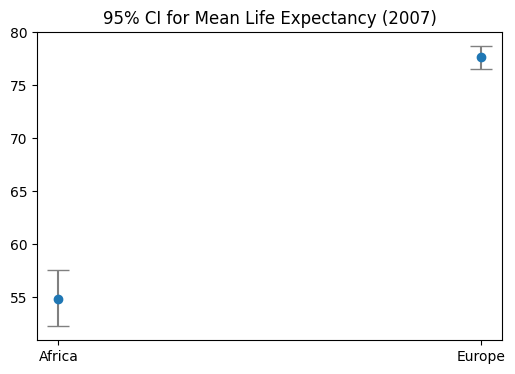

In [12]:
def bootstrap_ci(v, n=2000):
    b = [np.mean(np.random.choice(v, size=len(v), replace=True)) for _ in range(n)]
    return np.mean(v), np.percentile(b, 2.5), np.percentile(b, 97.5)
# Task 3: Honest Estimates with CIs
res_a = bootstrap_ci(gap_latest[gap_latest.continent == "Africa"].lifeExp.values)
res_b = bootstrap_ci(gap_latest[gap_latest.continent == "Europe"].lifeExp.values)
plt.figure(figsize=(6, 4))
plt.errorbar(["Africa", "Europe"], [res_a[0], res_b[0]],
             yerr=[[res_a[0]-res_a[1], res_b[0]-res_b[1]], [res_a[2]-res_a[0], res_b[2]-res_b[0]]],
             fmt='o', capsize=8, ecolor='gray')
plt.title("95% CI for Mean Life Expectancy (2007)")
plt.show()

**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

_Your answer:_

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

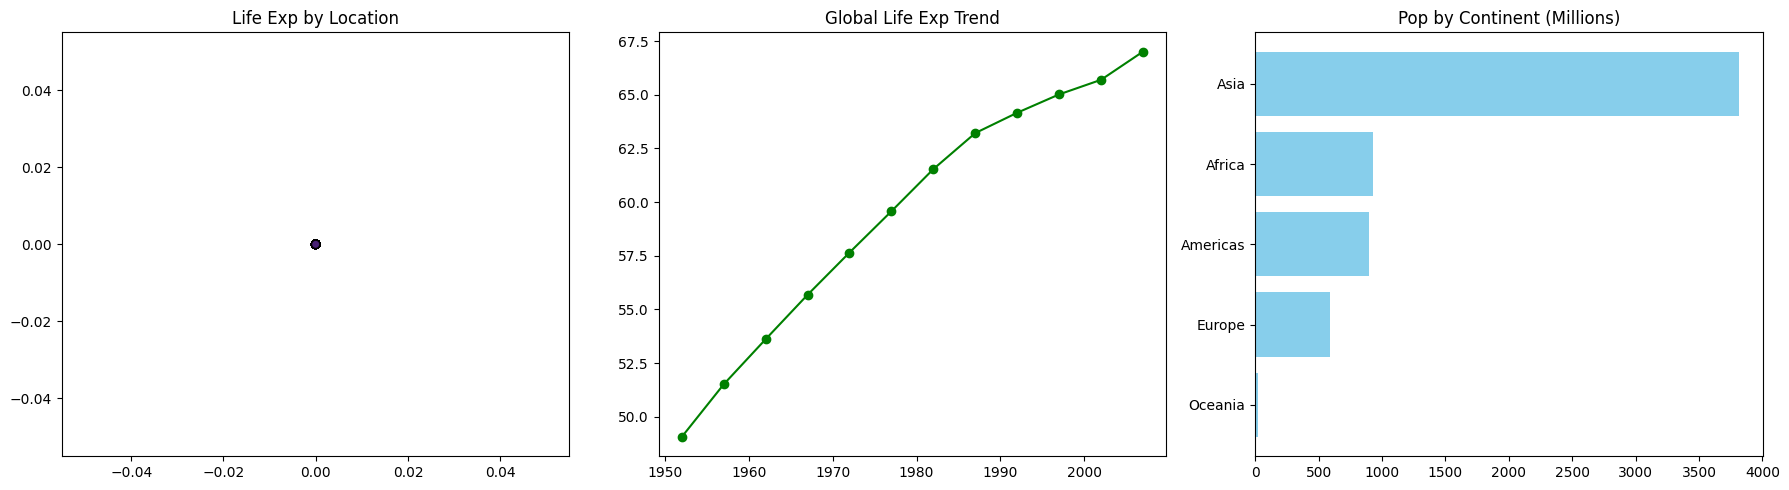

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
# Task 4: Morning Dashboard
ax[0].scatter(gap_latest.longitude, gap_latest.latitude, c=gap_latest.lifeExp, cmap='viridis', edgecolors='k')
ax[0].set_title("Life Exp by Location")
world_trend = gapminder.groupby("year")["lifeExp"].mean()
ax[1].plot(world_trend.index, world_trend.values, marker='o', color='green')
ax[1].set_title("Global Life Exp Trend")
pop_cont = gap_latest.groupby("continent")["pop"].sum().sort_values()
ax[2].barh(pop_cont.index, pop_cont.values/1e6, color='skyblue')
ax[2].set_title("Pop by Continent (Millions)")
plt.tight_layout()
plt.show()

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_

**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_

Answers:

Task-1:
Ans:The top-5 countries are different because total GDP depends on the population of a country, while GDP per capita shows GDP per person. I would choose the GDP per capita map because it gives a better comparison between countries of different population sizes.

Task-2:
Ans:For Norway, gdpPercap contributed the most positively to the predicted life expectancy. SHAP explains the contribution of each feature for one particular prediction. This is different from global feature importance, which shows the importance of features for the whole model.

Task-3:
Ans:Africa has the wider confidence interval. This is mainly because there is more variation in life expectancy among African countries. Sample size can also affect the width of the confidence interval.

Task-4:
Ans:I would keep the global life expectancy trend panel. It quickly shows whether life expectancy is increasing or decreasing over the years. It is useful for identifying important trends at a glance.

Task-5:
Ans:I would use the rate-based map because it gives a better comparison between countries of different population sizes. For a specific country, I would use local feature importance because it explains why the model made that particular prediction. Global feature importance explains the model as a whole. The mean life expectancy should not be shown as a bare point estimate because it is only an estimate and has uncertainty. Confidence intervals make the result clearer and more reliable.

